# AutoEIT — Transcription Quality: FastConformer vs. whisper/parakeet/wav2vec2/crisperwhisper (resegmented, hit recordings)

[NVIDIA Spanish FastConformer Hybrid Transducer-CTC](https://huggingface.co/nvidia/stt_es_fastconformer_hybrid_large_pc)
(`nvidia/stt_es_fastconformer_hybrid_large_pc`) is a monolingual Spanish acoustic model, decoded via
its **CTC head** rather than its RNNT head (see `src/transcription/transcribe_fastconformer.py`).
CTC is a frame-synchronous classifier with no autoregressive language-model component, so unlike
Whisper's decoder it has no mechanism to "correct" disfluent speech toward a more fluent,
grammatical hypothesis — it can only emit what the acoustic encoder actually heard. This makes it a
more direct test of the verbatim-preservation goal than Canary (a candidate still being evaluated
separately), at the cost of being a narrower, monolingual (Spanish-only) model with no per-word
confidence output (`mean_word_prob` is always null, same as Parakeet).

It was run via `src/transcription/transcribe_resegmented_fastconformer.py` over every recording in
`data/segmented/v2/` (hit and miss alike, unlike CrisperWhisper which was restricted to hits), then
merged with the existing whisper/parakeet/wav2vec2/crisperwhisper outputs and the human-rater
transcriptions via `src/postprocessing/build_postprocessed_csv_resegmented.py` (same rank-based
item&lt;-&gt;Sentence alignment and WER/MER/CER scoring as the other resegmented-transcription-quality
notebooks). A plain 4-column (stimuli / rater1 / rater2 / fastconformer) reviewable transcript sheet
is written separately by `src/postprocessing/build_fastconformer_excel.py` to
`data/postprocessed/fastconformer/fastconformer_transcriptions.xlsx`.

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] — doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** — the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation (see `normalize_text` in
`build_postprocessed_csv.py`), scored against both human raters, restricted to the 102 hit
recordings where the rank-based item&lt;-&gt;Sentence alignment is trustworthy.

## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "crisperwhisper", "fastconformer"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

29395 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see
`analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown
alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "parakeet": "#DD8452",
    "wav2vec2": "#55A868",
    "crisperwhisper": "#C44E52",
    "fastconformer": "#8172B2",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## Hit recordings (n=102, both raters), all 5 ASR systems vs. human floor

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297
human,0.1608,0.1501,0.0763,0.1111,0.1111,0.0250,0.429


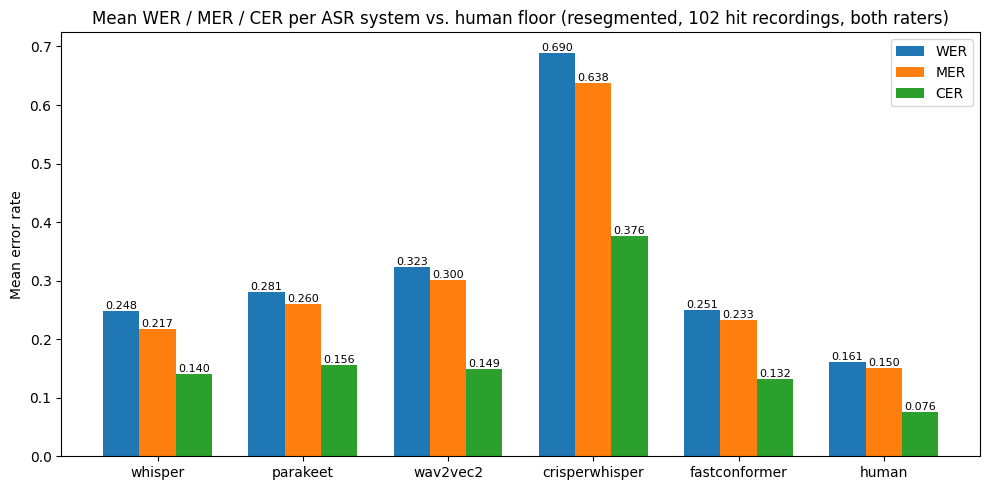

In [7]:
plot_metrics(
    scores_with_human,
    "Mean WER / MER / CER per ASR system vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/fastconformer_transcription_quality_metrics.png",
    order=DISPLAY_SOURCES,
)

## FastConformer vs. the previous best (whisper) only

Isolating the head-to-head comparison that motivated trying FastConformer: does a monolingual
Spanish CTC model -- with no autoregressive decoder to smooth over disfluencies, and no per-word
confidence signal -- score competitively against Whisper large-v3, the best of the original three
candidates?

In [8]:
summarize(scores, order=["whisper", "fastconformer"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297


## FastConformer vs. CrisperWhisper

Both are pitched as more "verbatim-leaning" than plain Whisper (CrisperWhisper via training
objective, FastConformer via its CTC decoding head with no language-model component) -- worth
comparing directly since they represent two different routes to the same goal.

In [9]:
summarize(scores, order=["crisperwhisper", "fastconformer"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297


## Takeaways

- FastConformer (mean WER 0.251) lands essentially tied with whisper (0.248) -- a ~0.003 gap that's
  well within noise for this dataset -- and actually edges whisper out on CER (0.132 vs. 0.140),
  despite having no autoregressive decoder to clean up its output and no per-word confidence signal
  to filter with.
- It clearly outperforms parakeet, wav2vec2, and crisperwhisper on all three metrics, making it the
  second-best system overall on this resegmented hit-recording set, in a near-tie with whisper for
  first.
- Against crisperwhisper specifically -- the other "verbatim-leaning" candidate -- FastConformer
  wins by a wide margin (WER 0.251 vs. 0.690), suggesting the CTC-head route to
  disfluency-preservation generalizes to these raters far better than CrisperWhisper's fine-tuning
  approach did.
- Both remain well above the human floor (WER 0.161), so there's still headroom, but FastConformer
  is now a credible alternative to whisper as the pipeline's primary ASR source -- worth a closer
  qualitative look (e.g. fused-word or repetition-collapse failure modes, as found for
  crisperwhisper) before considering a swap.